# 01 Long-tailed distribution

Workflow:
1. Read filtered detections.
2. Build and save a category-level intermediate summary (one category per row).
3. Read intermediate summary for all downstream analyses and figures.



In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Use Lato if installed; fallback to generic sans-serif if unavailable.
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Lato", "DejaVu Sans", "Arial", "Liberation Sans"]

# Resolve project root from this notebook location: analysis/preprint-2026/
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
FRAME_DATA_CSV = PROJECT_ROOT / "frame_data" / "merged_frame_detections_with_metadata_filtered-0.27.csv"
CDI_CSV = DATA_DIR / "cdi_words.csv"
INCLUDED_CATEGORIES_TXT = DATA_DIR / "included_categories.txt"
OUTPUT_INTERMEDIATE = DATA_DIR / "long_tailed_dist_prop_included_categories.csv"
OUTPUT_FIG_DIR = PROJECT_ROOT / "analysis" / "preprint-2026" / "figures"
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Color palette aligned with ccn-2025/long_tailed_distribution_163cats.py
CDI_SEMANTIC_ORDER = [
    "animals", "body_parts", "clothing", "food_drink", "furniture_rooms",
    "household", "outside", "people", "toys", "vehicles", "other",
]
CDI_SEMANTIC_COLORS = {
    "animals": "#4DB8A8",
    "body_parts": "#E87A5F",
    "clothing": "#9B7EC8",
    "food_drink": "#E8A54C",
    "furniture_rooms": "#6BAB7A",
    "household": "#D97B9E",
    "outside": "#5B9BD5",
    "people": "#E8C44C",
    "toys": "#B07CC8",
    "vehicles": "#6BA3D5",
    "other": "#8B9A9E",
}


def _apply_axis_style(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", labelsize=13, width=1.2)


In [5]:
# 1) Build category-level intermediate summary from filtered detections.
#    Inclusion is defined by data/included_categories.txt.
#    Output columns: category, proportion, cdi_semantic (one row per included category).

# Read included categories list
included_categories = [
    line.strip().lower()
    for line in INCLUDED_CATEGORIES_TXT.read_text().splitlines()
    if line.strip()
]
included_set = set(included_categories)

# Read filtered detections (one row per detected object)
df_det = pd.read_csv(FRAME_DATA_CSV, usecols=["class_name"])
df_det["class_name"] = df_det["class_name"].astype(str).str.strip().str.lower()

# Keep only included categories
df_det = df_det[df_det["class_name"].isin(included_set)].copy()

# Read CDI semantic mapping (uni_lemma -> category)
df_cdi = pd.read_csv(CDI_CSV, usecols=["uni_lemma", "category"])
df_cdi["uni_lemma"] = df_cdi["uni_lemma"].astype(str).str.strip().str.lower()
df_cdi["category"] = df_cdi["category"].astype(str).str.strip().str.lower()
lemma_to_semantic = (
    df_cdi.drop_duplicates(subset=["uni_lemma"], keep="first")
    .set_index("uni_lemma")["category"]
    .to_dict()
)

# Aggregate detection counts
counts = df_det.groupby("class_name").size().to_dict()
total_detected = int(sum(counts.values()))

# One row per included category (include 0 for never-detected categories)
df_cat = pd.DataFrame({"category": included_categories})
df_cat["count_detected"] = df_cat["category"].map(lambda c: int(counts.get(c, 0)))
df_cat["proportion"] = (
    df_cat["count_detected"] / total_detected if total_detected else 0.0
)
df_cat["cdi_semantic"] = df_cat["category"].map(lambda x: lemma_to_semantic.get(x, "other"))
df_cat = df_cat.sort_values("proportion", ascending=False).reset_index(drop=True)

# Write requested intermediate file
df_cat[["category", "proportion", "cdi_semantic"]].to_csv(OUTPUT_INTERMEDIATE, index=False)

print(f"Saved intermediate file: {OUTPUT_INTERMEDIATE}")
print(f"Included categories: {len(included_categories)}")
print(f"Detected rows retained (included categories only): {total_detected}")
df_cat.head(10)


Saved intermediate file: /home/j7yang/babyview-projects/vss2026/object-detection/data/long_tailed_dist_prop_included_categories.csv
Included categories: 129
Detected rows retained (included categories only): 2558108


,category,count_detected,proportion,cdi_semantic
0,chair,262155,0.102480,furniture_rooms
1,lamp,200703,0.078458,household
2,table,164742,0.064400,furniture_rooms
3,couch,162456,0.063506,furniture_rooms
4,pillow,143127,0.055950,household
5,cup,105120,0.041093,household
6,toy,103218,0.040349,toys
7,bed,85036,0.033242,furniture_rooms
8,bowl,84414,0.032999,household
9,plate,73273,0.028643,household


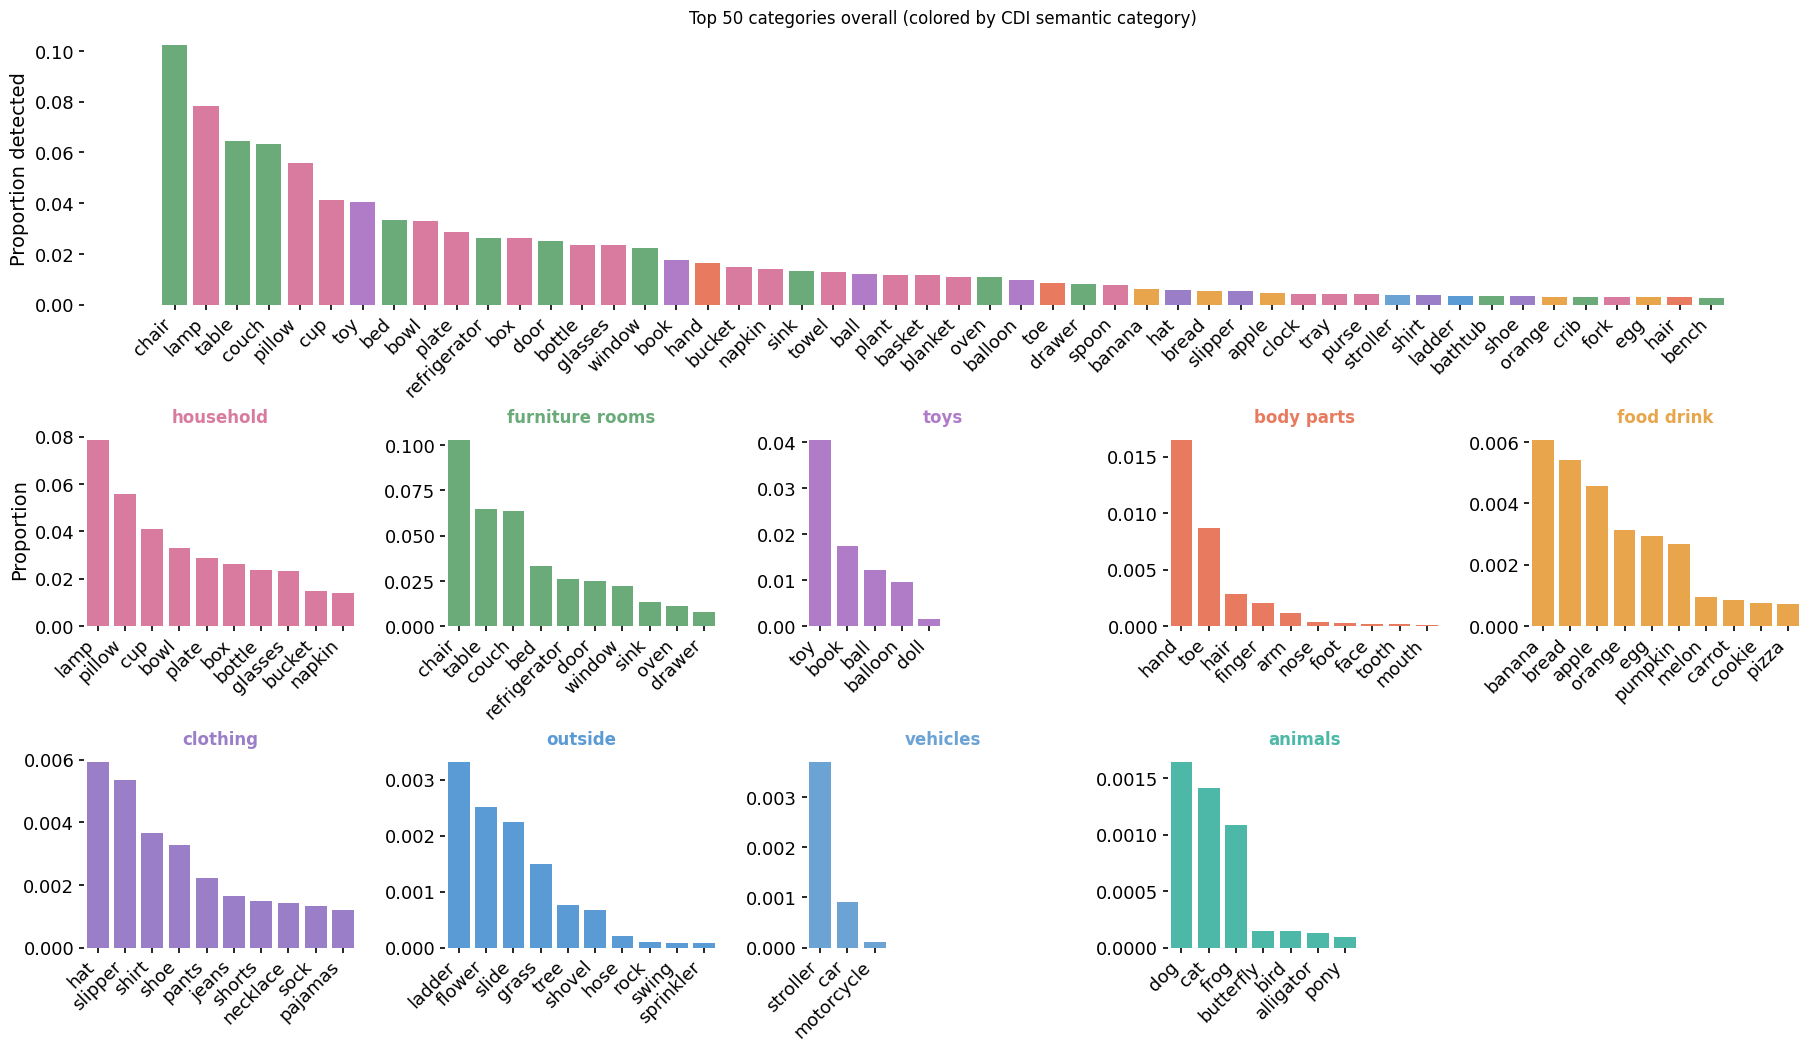

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/long_tailed_top50_plus_semantic_subplots.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/long_tailed_top50_plus_semantic_subplots.pdf


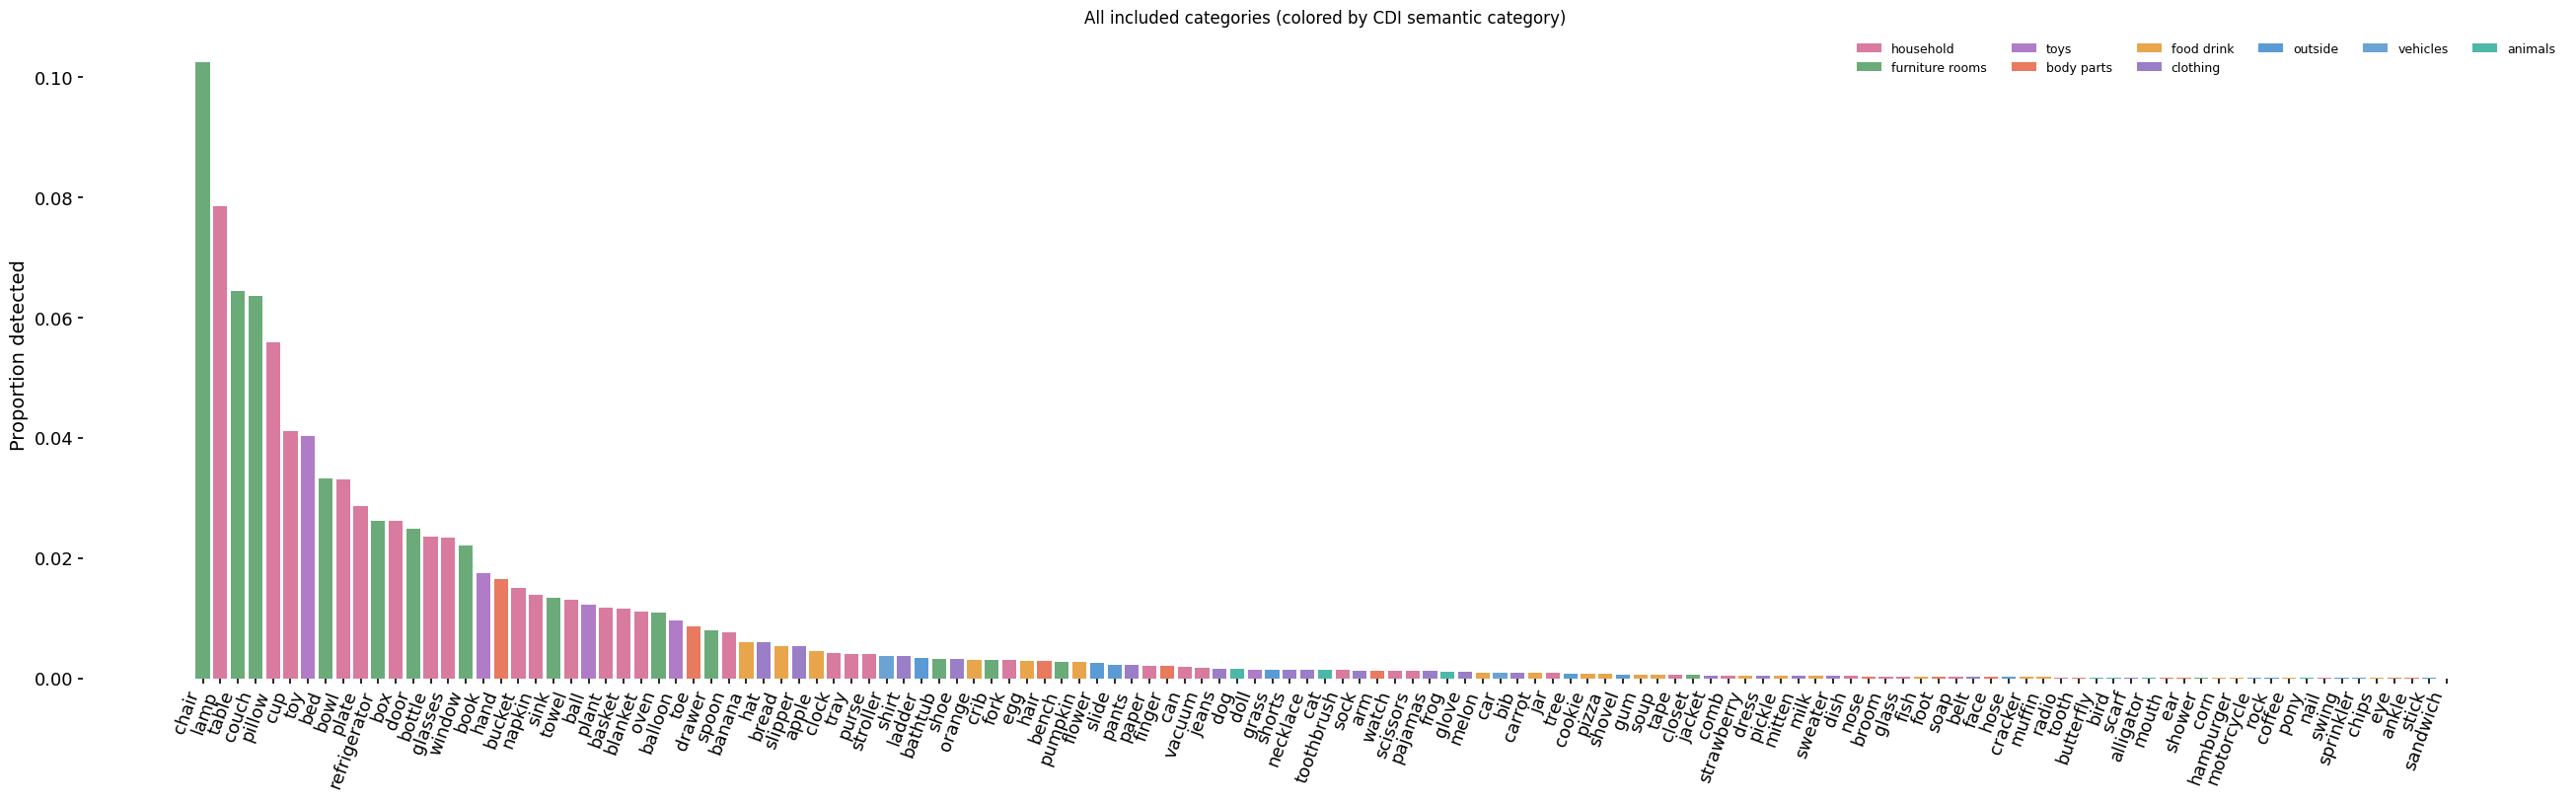

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/long_tailed_all_included_categories.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/figures/long_tailed_all_included_categories.pdf


In [6]:
# 2) Plot long-tailed distribution:
#    - Combined panel with top-50 categories (color-coded by cdi_semantic)
#    - Subplots for each cdi semantic category (top 10 within each)
#    - Additional figure for all included categories

# Read from intermediate so downstream steps always use the same source
df_plot = pd.read_csv(OUTPUT_INTERMEDIATE)
df_plot["category"] = df_plot["category"].astype(str).str.strip().str.lower()
df_plot["cdi_semantic"] = df_plot["cdi_semantic"].astype(str).str.strip().str.lower()
df_plot = df_plot.sort_values("proportion", ascending=False).reset_index(drop=True)

# Keep only semantics that exist in this dataset, then sort subplot order by total frequency
semantic_present = [s for s in CDI_SEMANTIC_ORDER if s in set(df_plot["cdi_semantic"])]
if len(semantic_present) == 0:
    semantic_present = sorted(df_plot["cdi_semantic"].dropna().unique().tolist())

semantic_rank = (
    df_plot[df_plot["cdi_semantic"].isin(semantic_present)]
    .groupby("cdi_semantic", as_index=False)["proportion"]
    .sum()
    .sort_values("proportion", ascending=False)
)
semantic_present = semantic_rank["cdi_semantic"].tolist()

# Small ordering override requested for presentation consistency.
if "furniture_rooms" in semantic_present and "household" in semantic_present:
    semantic_present.remove("furniture_rooms")
    household_idx = semantic_present.index("household")
    semantic_present.insert(household_idx, "furniture_rooms")

# Figure layout: top row full-width + semantic subplots beneath
# Use a balanced grid for semantic panels so there is no "orphan" subplot on the last row.
n_sem = len(semantic_present)
if n_sem <= 4:
    n_cols = max(1, n_sem)
elif n_sem <= 6:
    n_cols = 3
elif n_sem <= 8:
    n_cols = 4
else:
    n_cols = 5
n_rows_sub = int(np.ceil(n_sem / n_cols)) if n_sem > 0 else 1

fig = plt.figure(figsize=(18, 4 + 3.2 * n_rows_sub), constrained_layout=True)
gs = GridSpec(1 + n_rows_sub, n_cols, figure=fig, height_ratios=[1.4] + [1] * n_rows_sub)

# Top panel: top-50 overall (no legend; semantic labels are in subplot titles)
ax_top = fig.add_subplot(gs[0, :])
top50 = df_plot.head(50).copy()
colors_50 = [CDI_SEMANTIC_COLORS.get(s, CDI_SEMANTIC_COLORS["other"]) for s in top50["cdi_semantic"]]
x50 = np.arange(len(top50))
ax_top.bar(x50, top50["proportion"], color=colors_50, edgecolor="none", width=0.8)
ax_top.set_xticks(x50)
ax_top.set_xticklabels(top50["category"], rotation=45, ha="right", fontsize=10)
ax_top.set_ylabel("Proportion detected", fontsize=14)
ax_top.set_title("Top 50 categories overall (colored by CDI semantic category)")
_apply_axis_style(ax_top)

# Semantic subplots: top 10 within each CDI semantic category
# Fix identical bar width and identical x-span across subplots for visual consistency.
for idx, sem in enumerate(semantic_present):
    row = 1 + idx // n_cols
    col = idx % n_cols
    ax = fig.add_subplot(gs[row, col])

    sub = (
        df_plot[df_plot["cdi_semantic"] == sem]
        .sort_values("proportion", ascending=False)
        .head(10)
    )

    x = np.arange(len(sub))
    color = CDI_SEMANTIC_COLORS.get(sem, CDI_SEMANTIC_COLORS["other"])
    ax.bar(x, sub["proportion"], color=color, edgecolor="none", width=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["category"], rotation=45, ha="right", fontsize=10)
    ax.set_xlim(-0.5, 9.5)  # same x-range for every subplot to keep bar size consistent
    if idx == 0:
        ax.set_ylabel("Proportion", fontsize=14)
    else:
        ax.set_ylabel("")
    ax.set_title(sem.replace("_", " "), color=color, fontsize=12, fontweight="bold")
    _apply_axis_style(ax)

# Hide any unused subplot slots
total_slots = n_rows_sub * n_cols
for j in range(n_sem, total_slots):
    row = 1 + j // n_cols
    col = j % n_cols
    ax_unused = fig.add_subplot(gs[row, col])
    ax_unused.axis("off")

out_png = OUTPUT_FIG_DIR / "long_tailed_top50_plus_semantic_subplots.png"
out_pdf = OUTPUT_FIG_DIR / "long_tailed_top50_plus_semantic_subplots.pdf"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_png}")
print(f"Saved figure: {out_pdf}")

# Additional figure: all included categories (single panel)
fig_all, ax_all = plt.subplots(figsize=(26, 8), constrained_layout=True)
colors_all = [CDI_SEMANTIC_COLORS.get(s, CDI_SEMANTIC_COLORS["other"]) for s in df_plot["cdi_semantic"]]
x_all = np.arange(len(df_plot))
ax_all.bar(x_all, df_plot["proportion"], color=colors_all, edgecolor="none", width=0.8)
ax_all.set_xticks(x_all)
ax_all.set_xticklabels(df_plot["category"], rotation=70, ha="right", fontsize=10)
ax_all.set_ylabel("Proportion detected", fontsize=14)
ax_all.set_title("All included categories (colored by CDI semantic category)")
_apply_axis_style(ax_all)

legend_handles_all = [
    Patch(facecolor=CDI_SEMANTIC_COLORS[k], label=k.replace("_", " "))
    for k in semantic_present
]
ax_all.legend(
    handles=legend_handles_all,
    ncol=min(6, len(legend_handles_all)),
    frameon=False,
    fontsize=12,
    loc="upper right",
)

out_all_png = OUTPUT_FIG_DIR / "long_tailed_all_included_categories.png"
out_all_pdf = OUTPUT_FIG_DIR / "long_tailed_all_included_categories.pdf"
fig_all.savefig(out_all_png, dpi=150, bbox_inches="tight")
fig_all.savefig(out_all_pdf, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_all_png}")
print(f"Saved figure: {out_all_pdf}")
